# Circle from Lines

Demonstrates how adding more and more sides to a polygon makes it look more circular.

new pipeline: painter_Tessellated_fill_solid_brush_solid_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_18030370004436334972_inarr_false


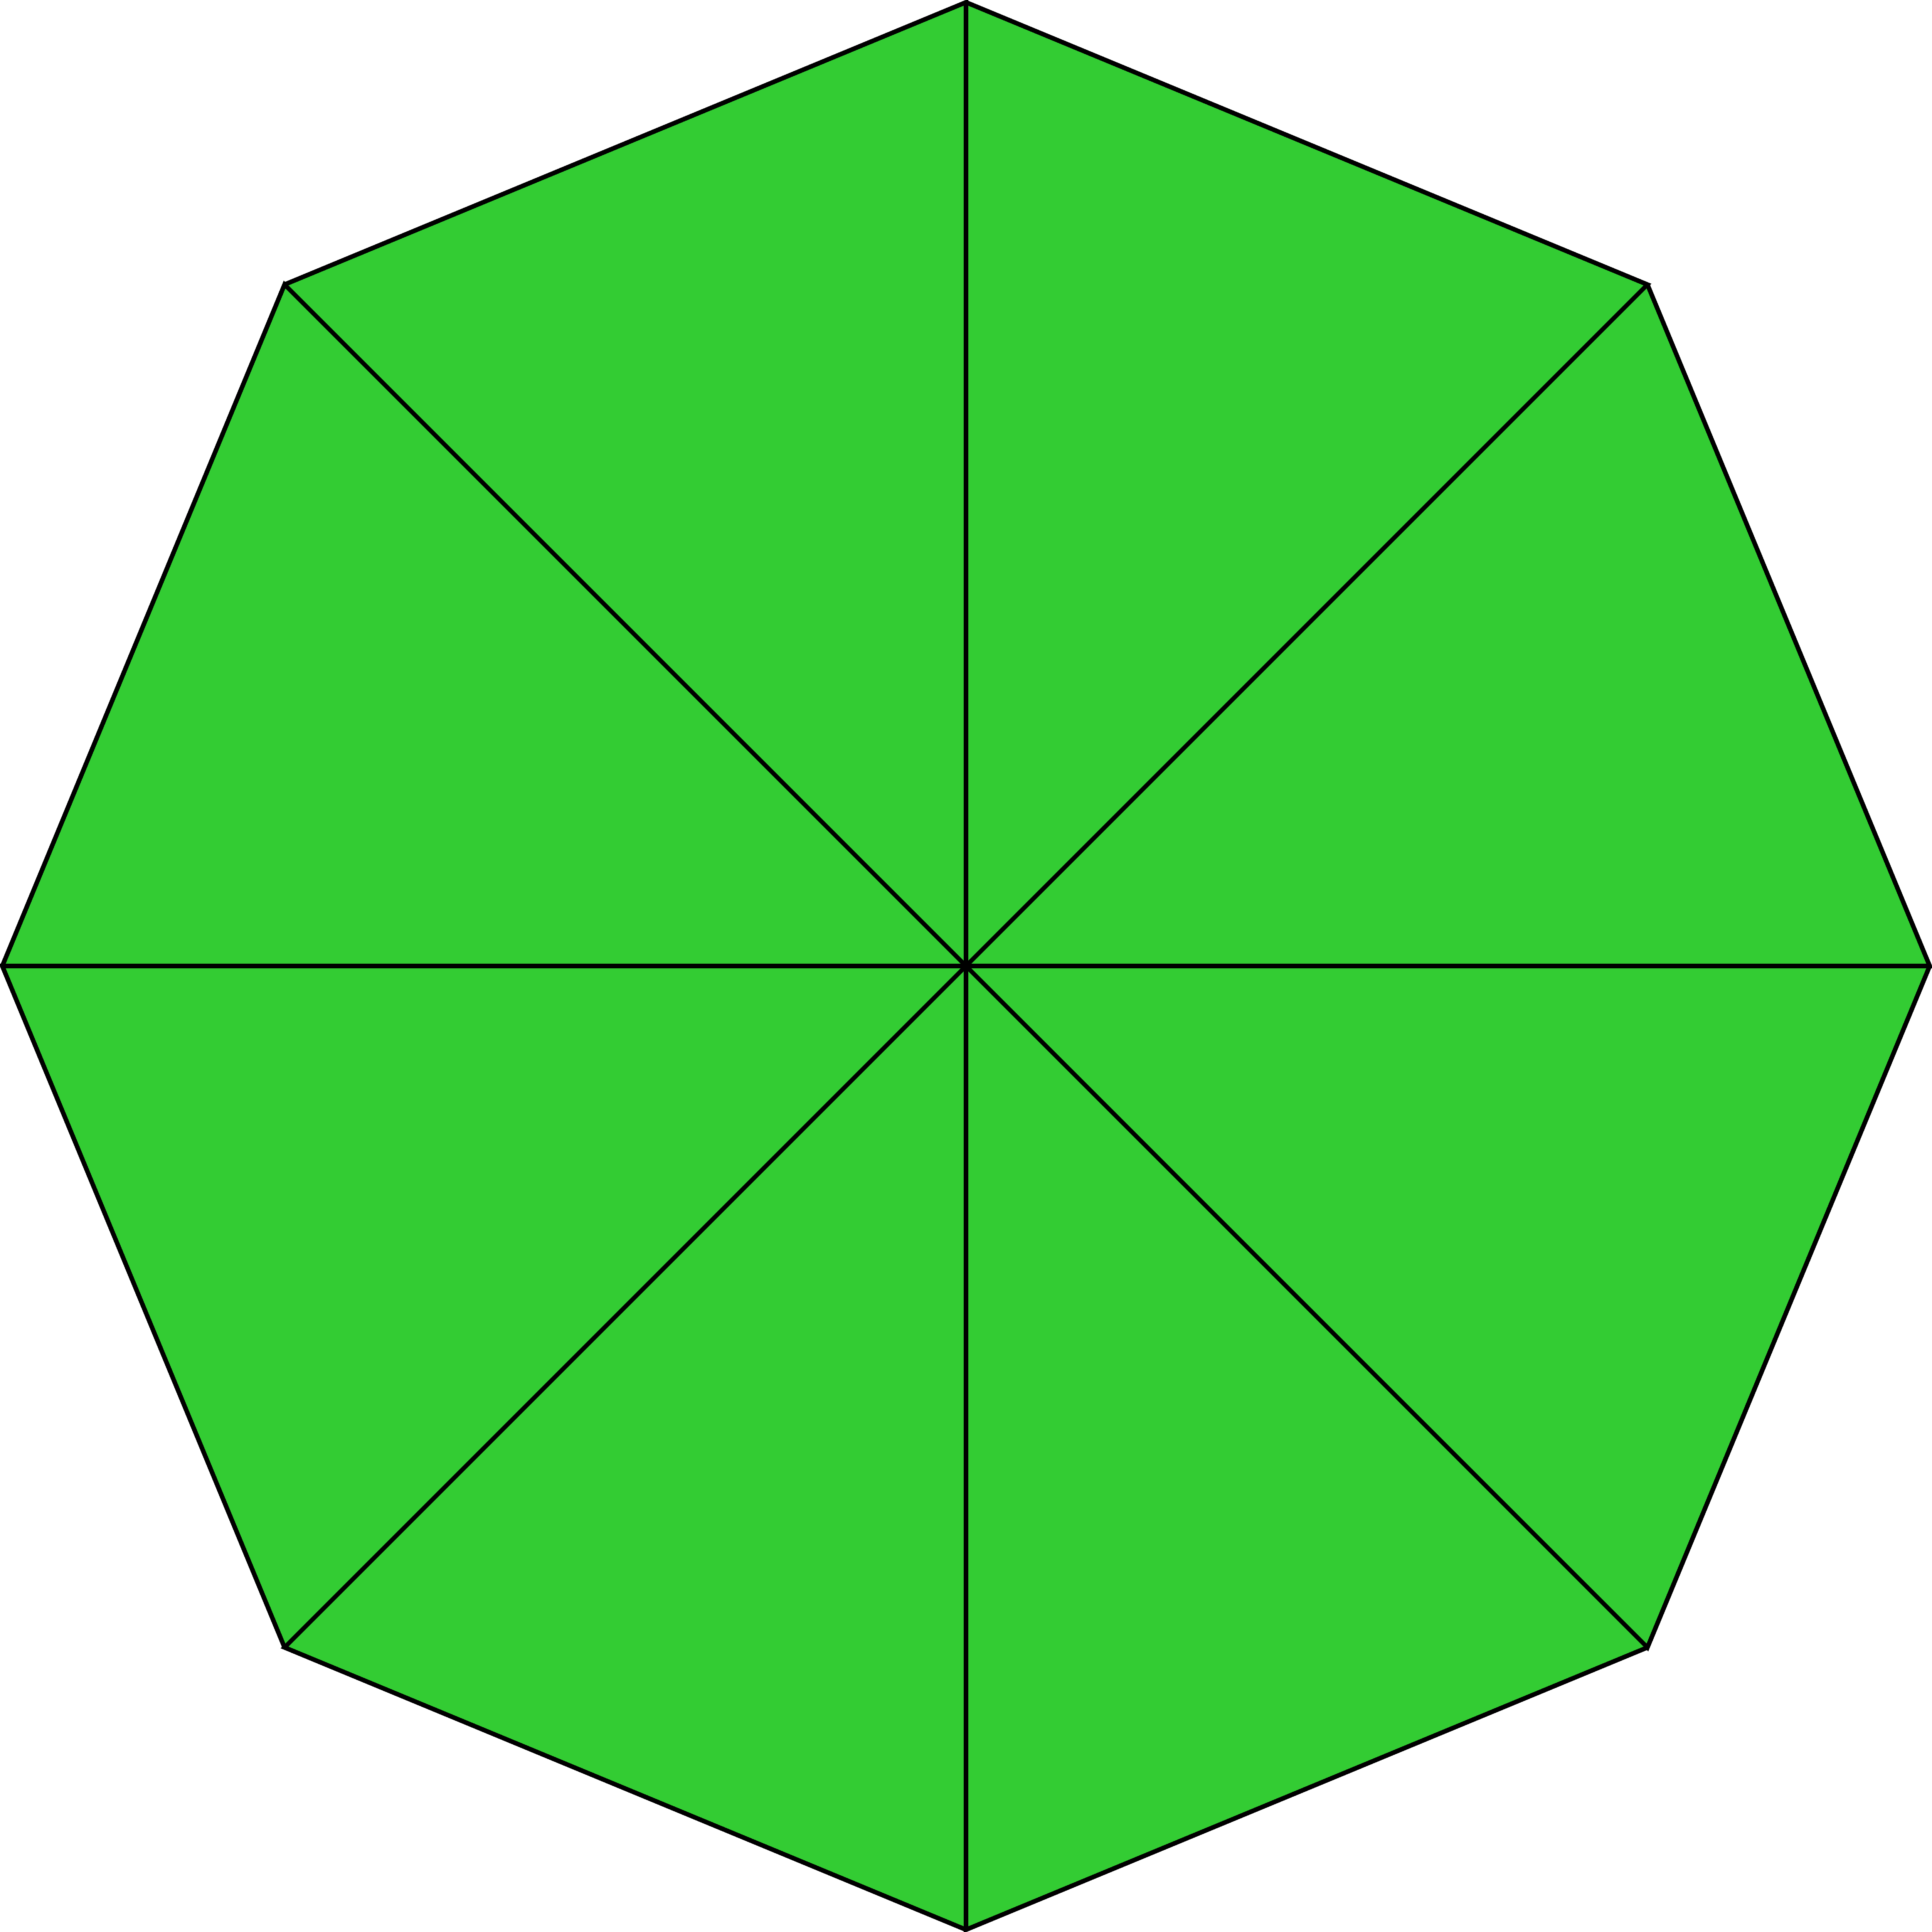

new pipeline: painter_Tessellated_fill_solid_brush_solid_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_18030370004436334972_inarr_false


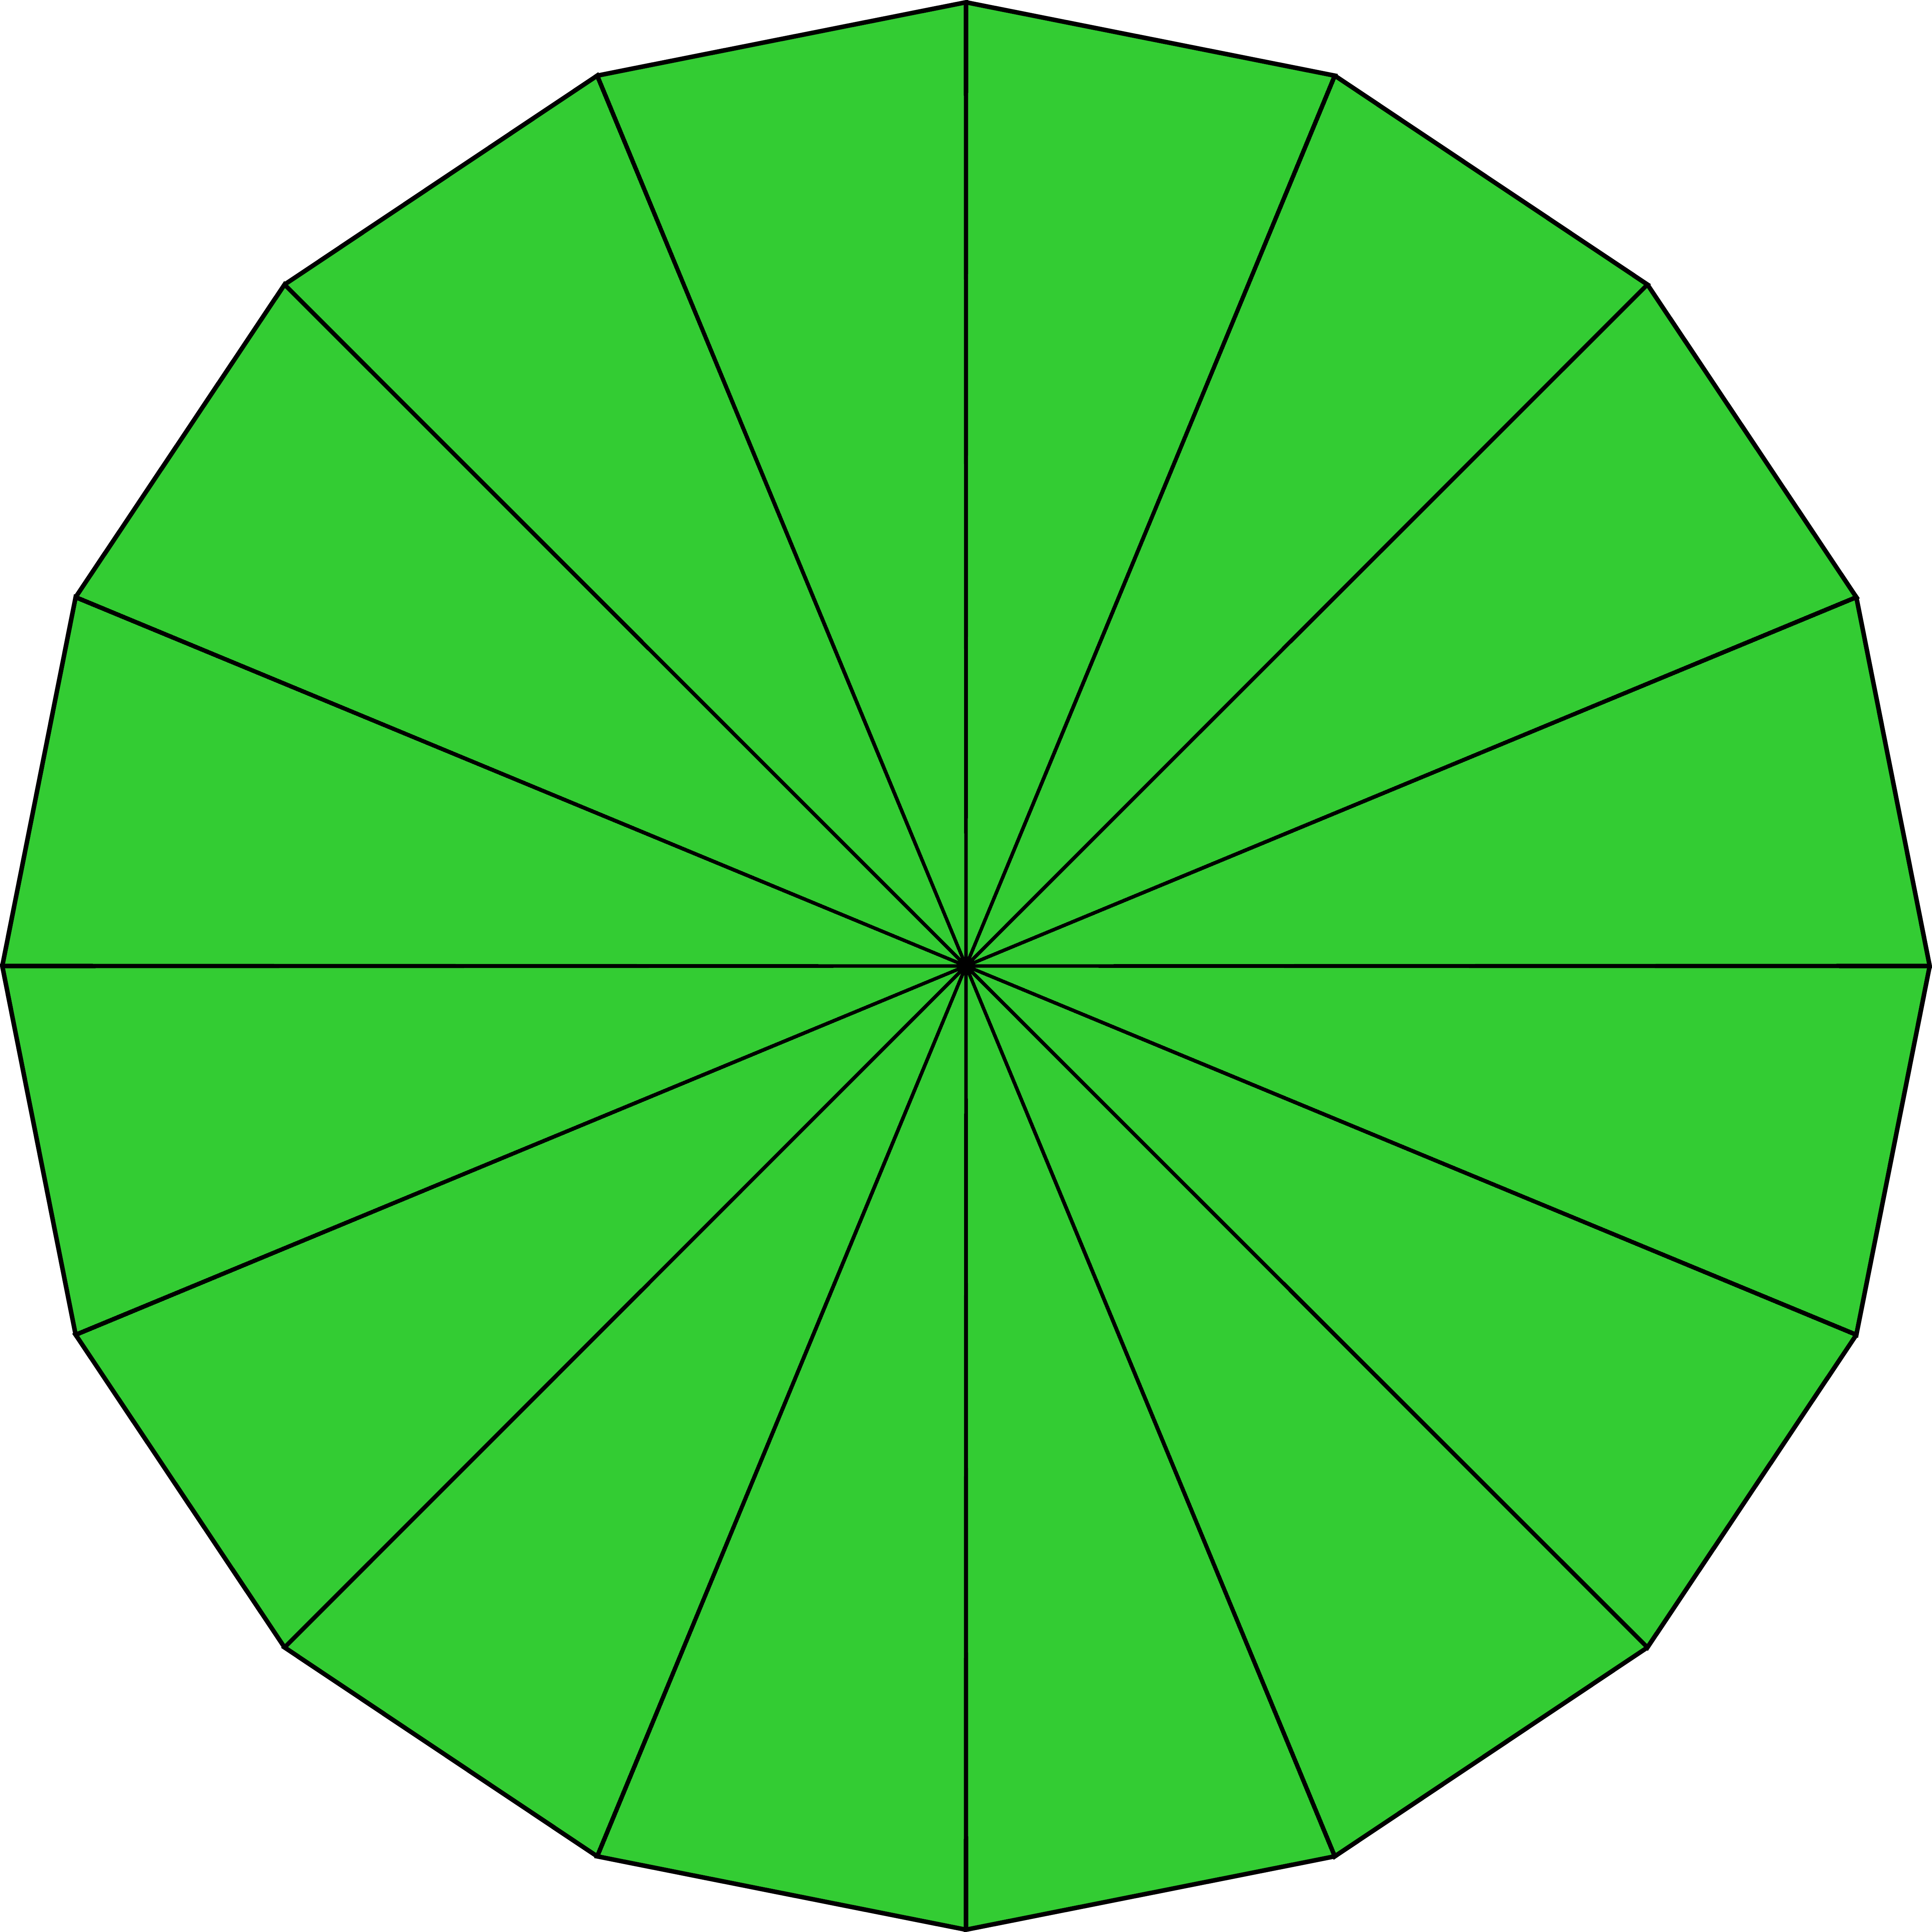

new pipeline: painter_Tessellated_fill_solid_brush_solid_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_18030370004436334972_inarr_false


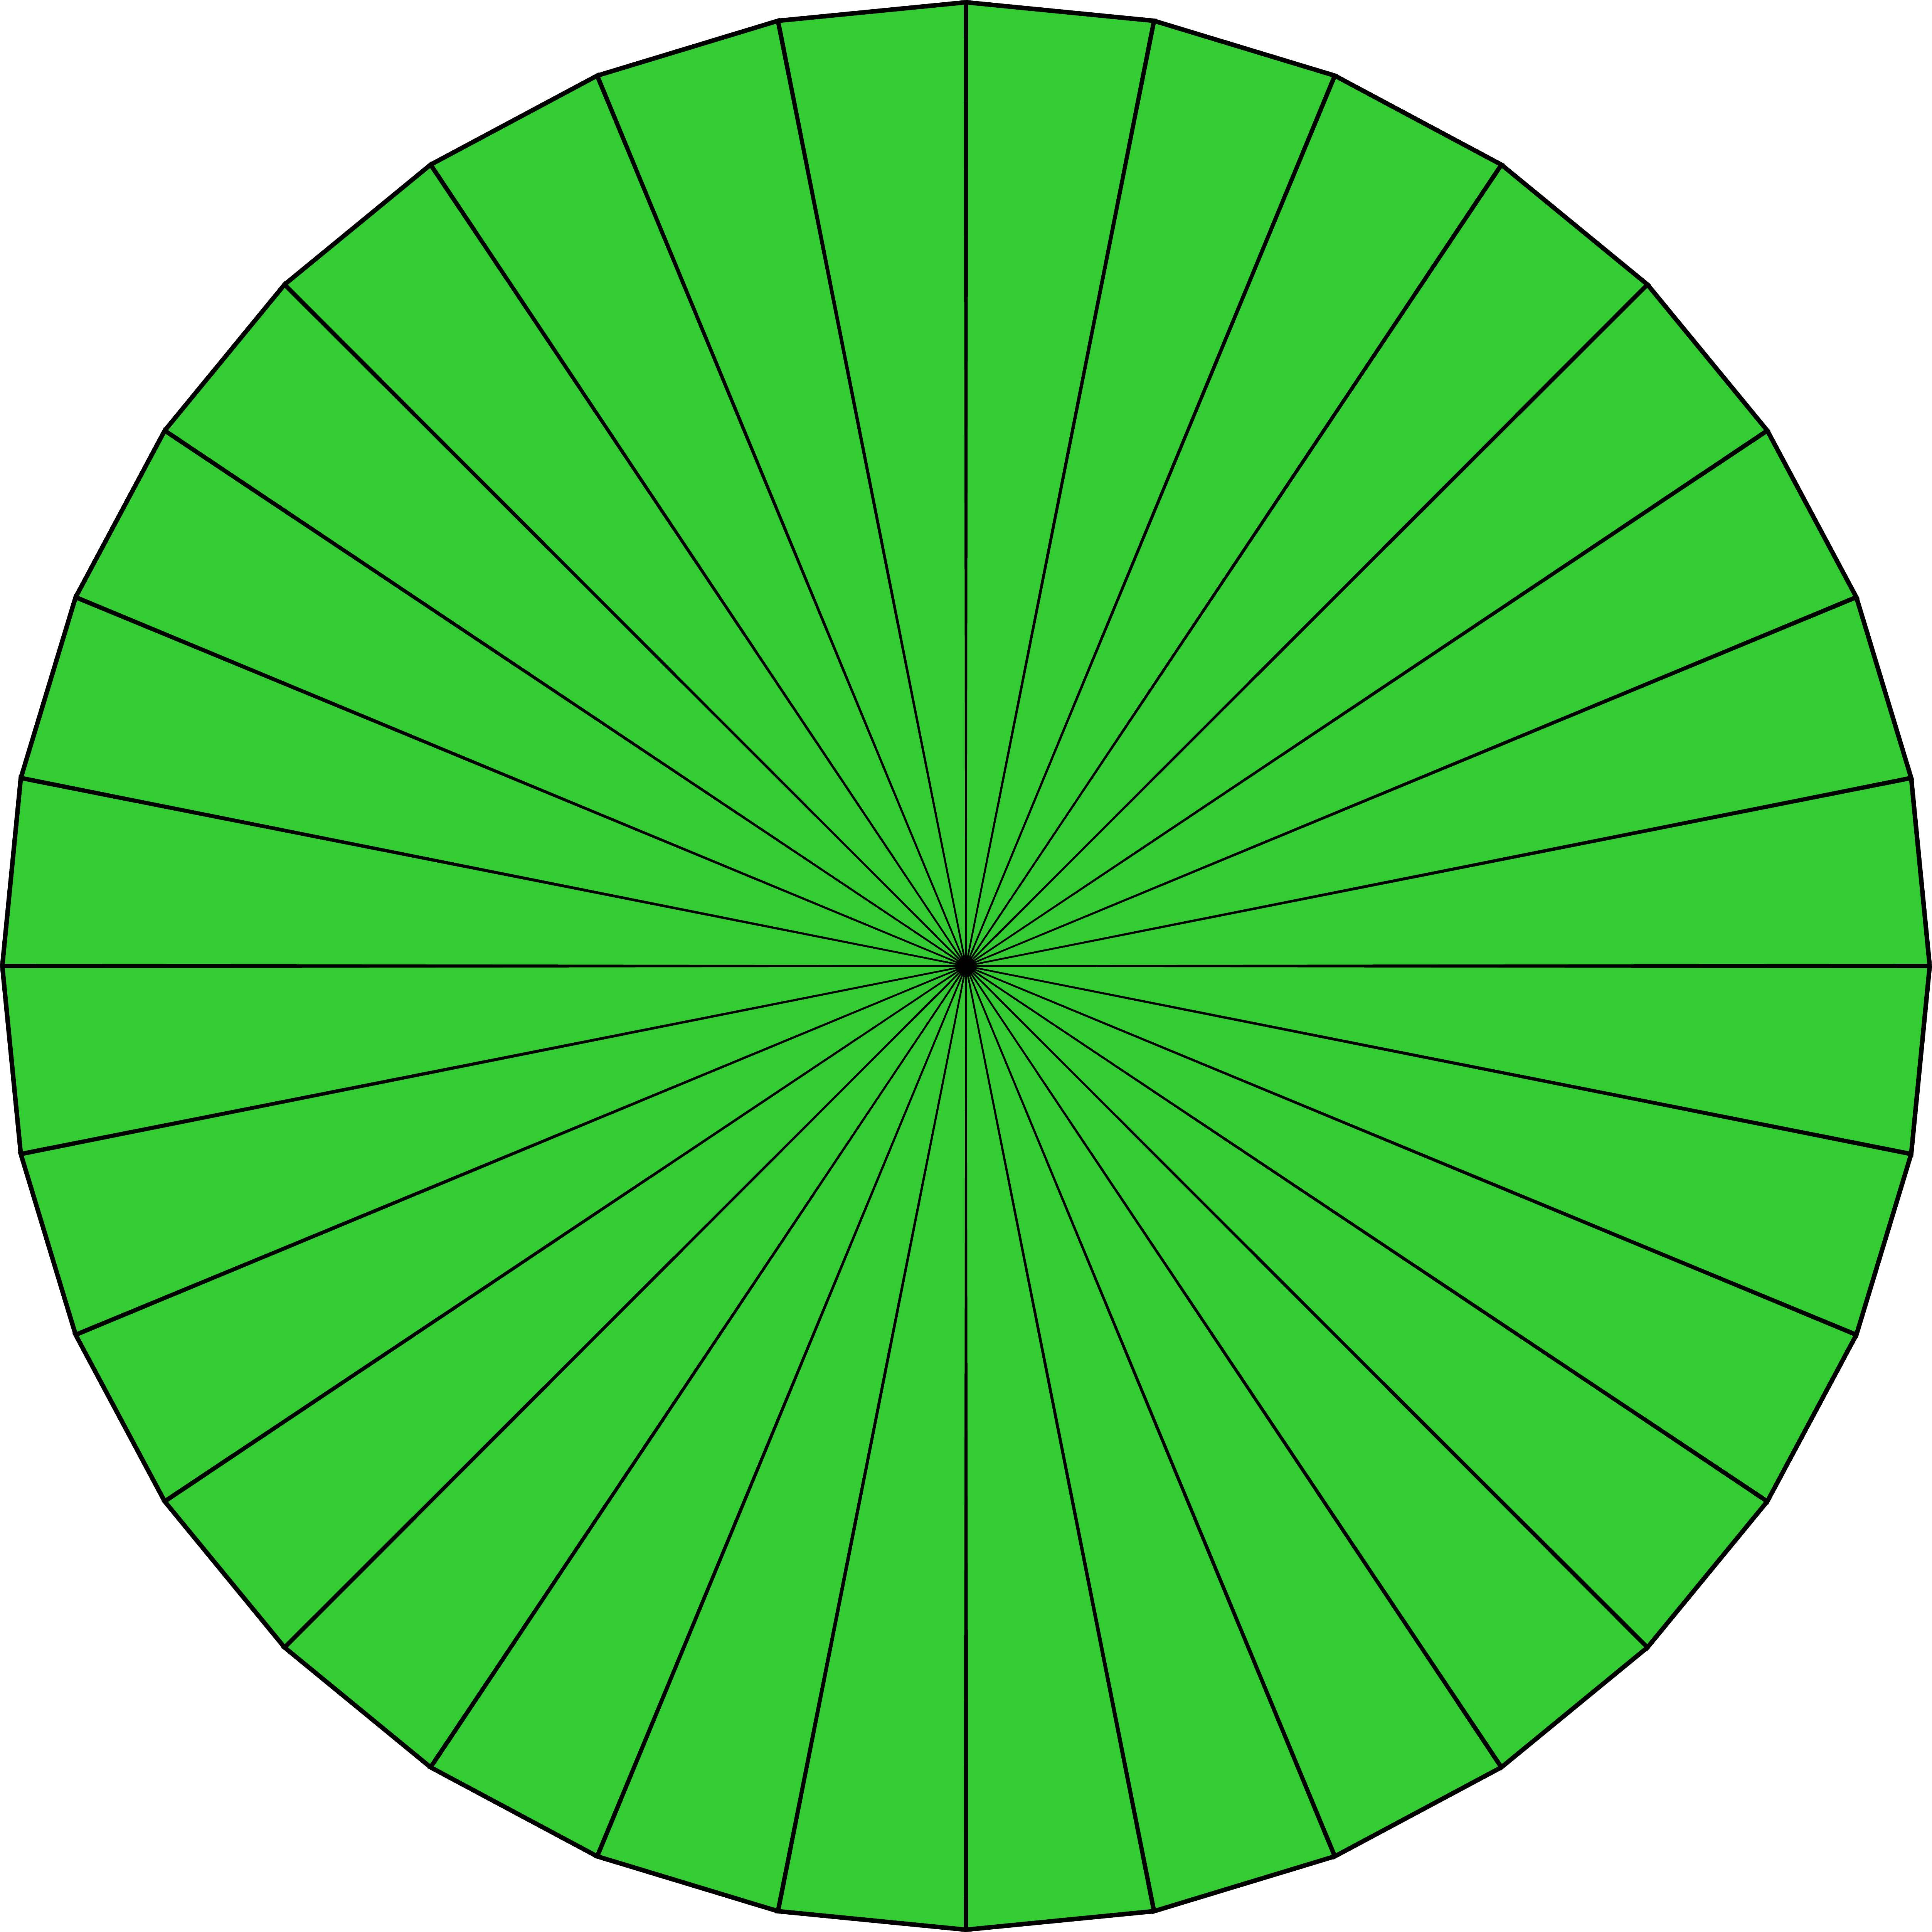

new pipeline: painter_Tessellated_fill_solid_brush_solid_sample_true_rgba16float
new pipeline: color_transformer_shader_rgba16float_compute_18030370004436334972_inarr_false


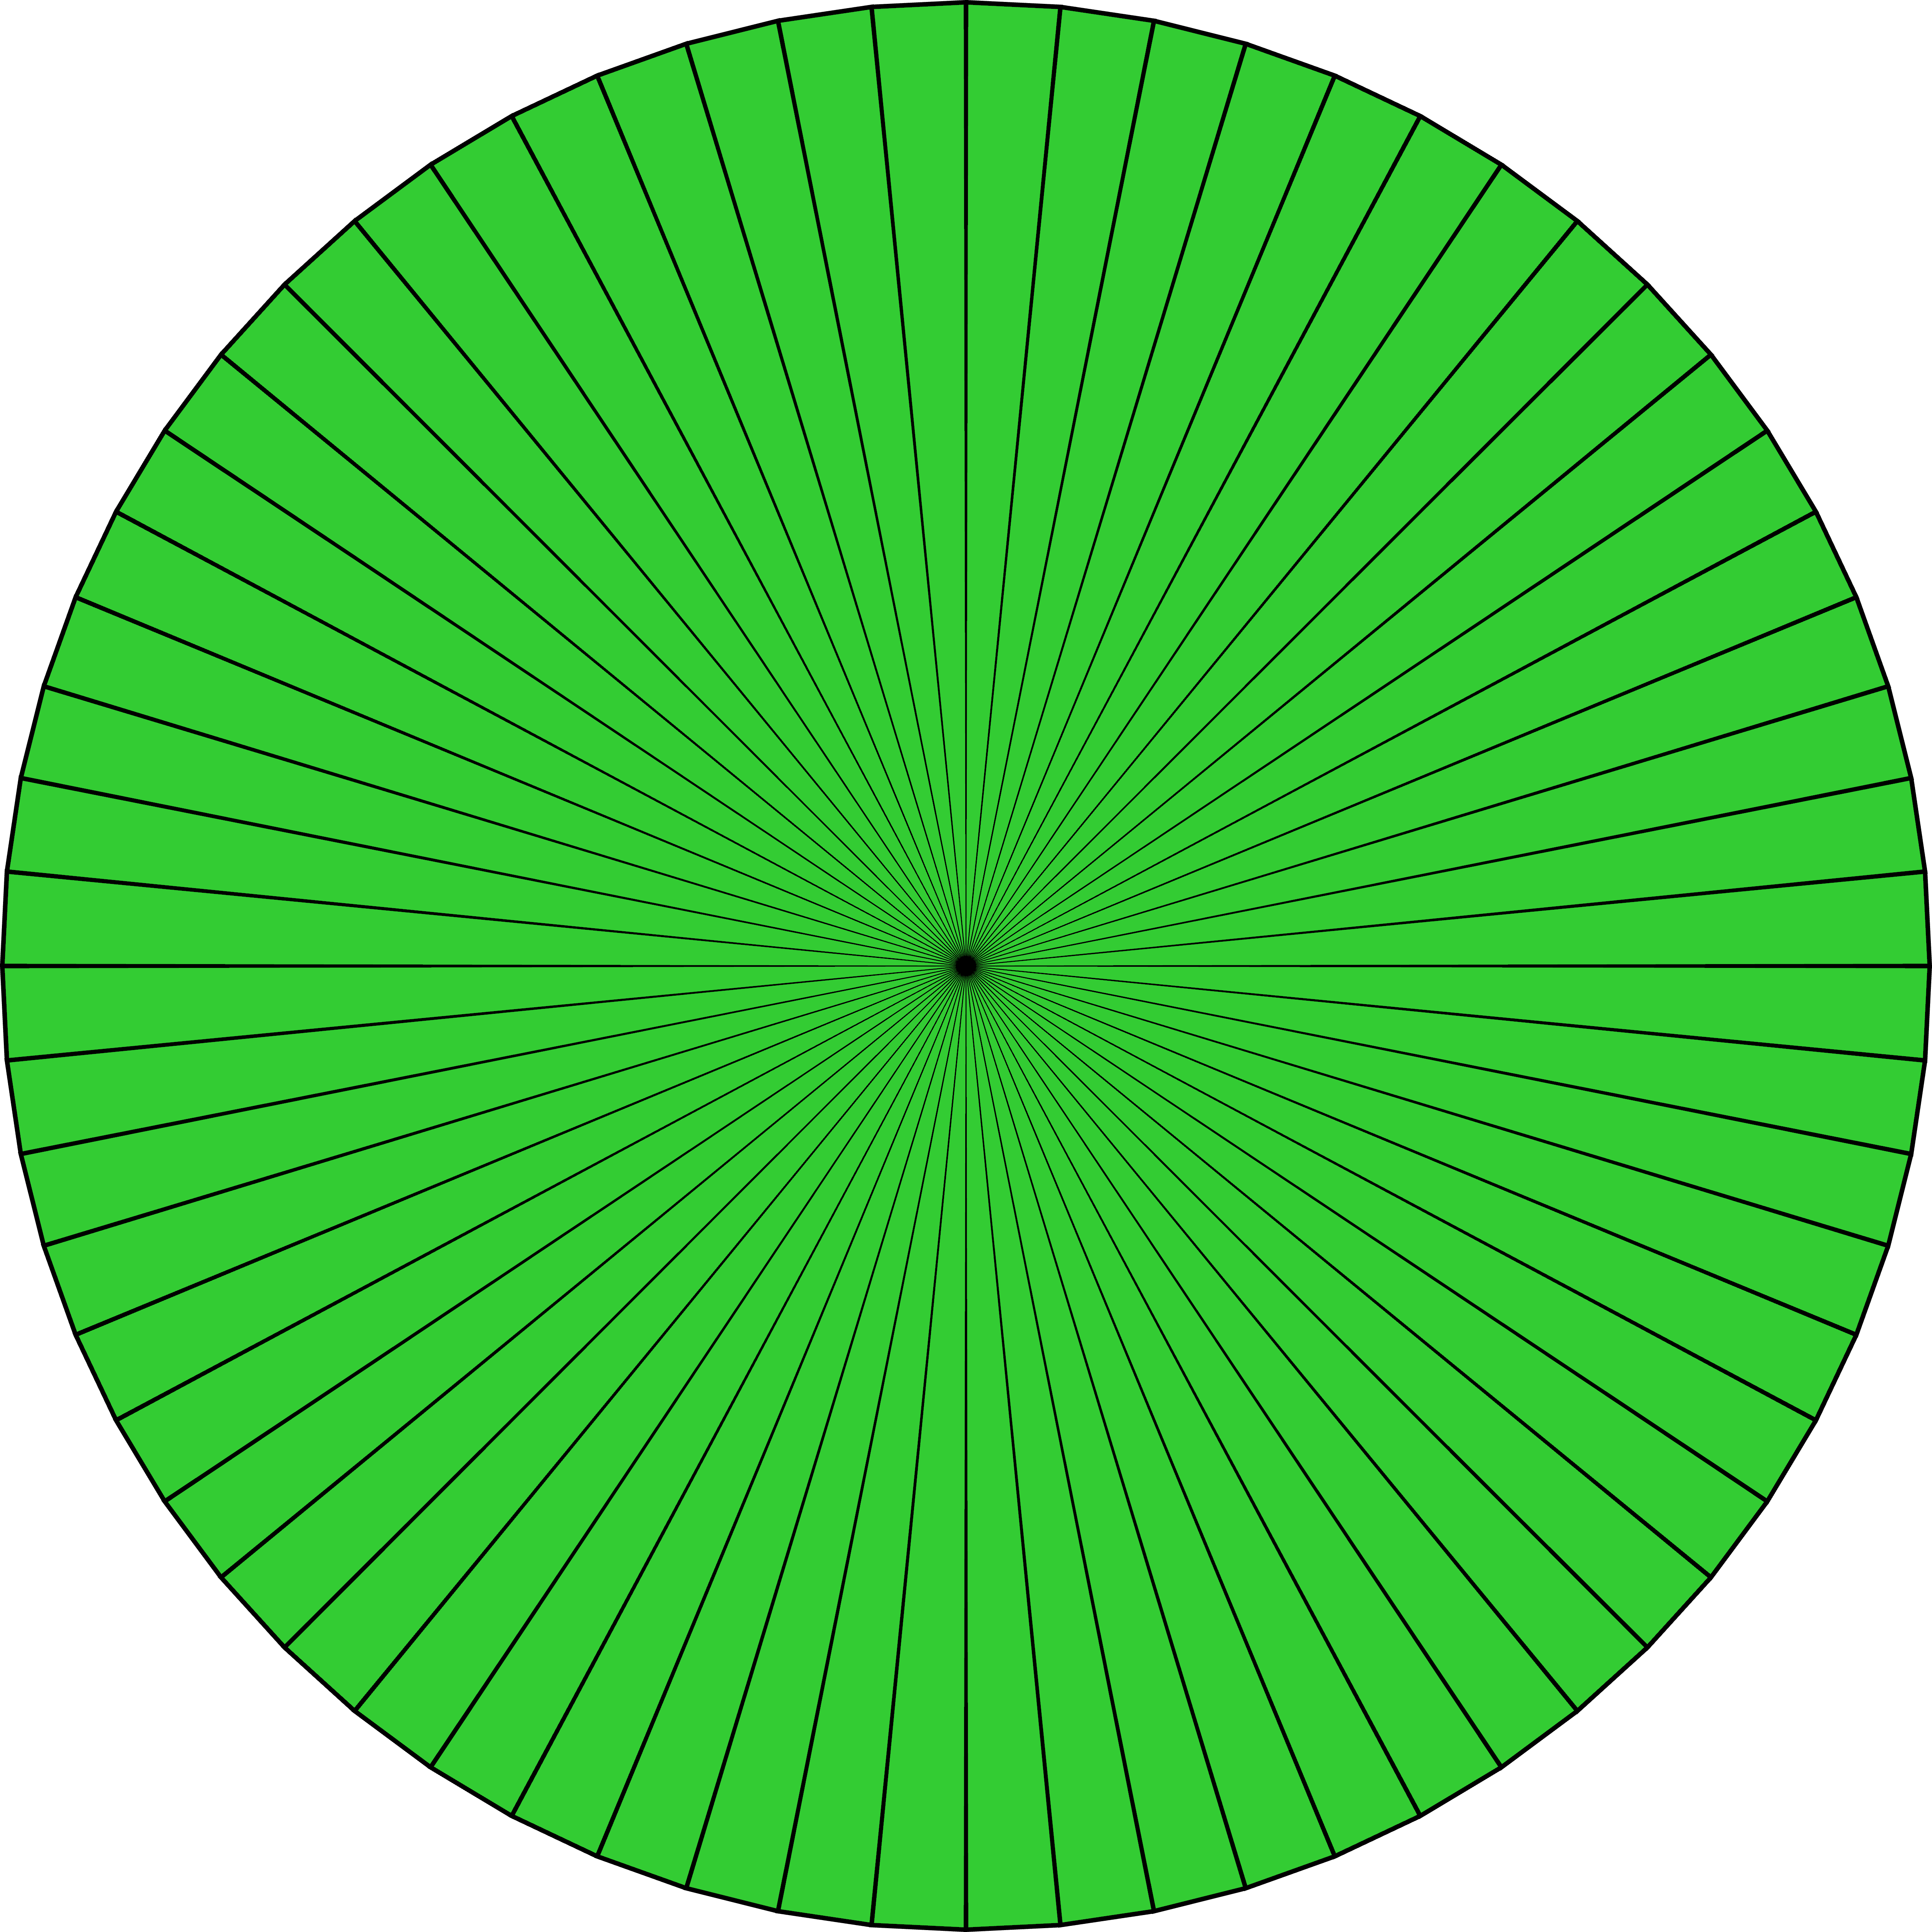

In [22]:
import math

import brushcue
from IPython.display import Image, display

RADIUS = 2500

def make_circle(number_of_items: int) -> brushcue.Composition:
    total_circle = math.tau
    step = total_circle / number_of_items
    painter = brushcue.Painter.new()
    fill = brushcue.Fill.solid(
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(0.2, 0.8, 0.2, 1.0)
        )
    )
    brush = brushcue.Brush.solid(
        brushcue.ProfiledColor.from_rgba_srgb(
            brushcue.RGBAColor.from_components(0.0, 0.0, 0.0, 1.0)
        ),
        6,
    )
    render_style = brushcue.RenderStyle.brush_and_fill(brush, fill)
    for i in range(number_of_items):
        path = brushcue.Path.new()
        path = path.move_to_point(
            brushcue.Point2f.from_components(math.cos(step * i) * RADIUS, math.sin(step * i) * RADIUS)
        )
        path = path.line_to_point(brushcue.Point2f.from_components(0, 0))
        path = path.line_to_point(
            brushcue.Point2f.from_components(
                math.cos(step * (i + 1)) * RADIUS,
                math.sin(step * (i + 1)) * RADIUS
            )
        )
        path = path.line_to_point(
            brushcue.Point2f.from_components(math.cos(step * i) * RADIUS, math.sin(step * i) * RADIUS)
        )
        painter = painter.add_path_with_render_style(
            path,
            render_style,
            brushcue.Transform2.identity().to_list()
        )
    return brushcue.Composition.painter(painter)

for i in [8, 16, 32, 64]:
    output_path = f"/home/dito/dev/monorepo/writing/graphics/chapters/gpu/assets/circle_{i}.png"
    composition = make_circle(i)
    ctx = brushcue.Context()
    image_bytes = composition.execute(ctx).to_image_bytes(ctx)
    with open(output_path, "wb") as f:
        f.write(image_bytes)
    display(Image(output_path))